# Galaxy Redshift Prediction with Cross-Attention Fusion Model


## 1. Setup

In [ ]:
import os, sys, csv, time
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

project_root = os.path.abspath("../")
sys.path.insert(0, project_root)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from tqdm.notebook import tqdm


from src.data_loader import BAND_MEAN, BAND_STD, load_split, get_fusion_dataloaders, MORPH_COLS
from src.models.crossattn import (LoRALinear, CrossAttentionFusion, MorphMLP, FusionModelCrossAttn, 
                                  RedshiftLoss, make_optimizer, make_scheduler, set_phase)
from src.utils import (set_seed, get_device, SPLIT_COLORS,
                       save_checkpoint, load_checkpoint,
                       full_evaluation, full_evaluation_extended,
                       plot_learning_curves, plot_pred_vs_true,
                       plot_binned_performance)
from src.metrics import redshift_metrics, evaluate_by_bin




In [3]:
set_seed(42)
device = get_device()

Using MPS (Apple Metal GPU)


## 2. Data

In [ ]:
BASE_DATA = os.path.abspath("../data/")
BASE_MODELS = os.path.abspath("../models/")
BASE_REPORTS = os.path.abspath("../reports/")
os.makedirs(BASE_MODELS, exist_ok=True)
data_dir = BASE_DATA + "/"
model_dir = BASE_MODELS + "/"

TRAIN_PATH = data_dir + "5x127x127_training_with_morphology.hdf5"
VAL_PATH = data_dir + "5x127x127_validation_with_morphology.hdf5"
TEST_PATH = data_dir + "5x127x127_testing_with_morphology.hdf5"

N_MORPH = len(MORPH_COLS)

save_path = model_dir + "fusion_crossattn_best_exp2.pt"
latest_path = model_dir + "fusion_crossattn_latest_exp2.pth"
csv_path = model_dir + "fusion_crossattn_metrics_exp2.csv"

print(f"Morphology features: {N_MORPH}")
for f in ["resnet_best.pth", "5x127x127_training_with_morphology.hdf5"]:
    path = (model_dir if "pth" in f or "pt" in f else data_dir) + f
    print(f"  {f}: {os.path.exists(path)}")

Morphology features: 60
  resnet_best.pth: True
  5x127x127_training_with_morphology.hdf5: True


In [5]:
df_train = load_split(TRAIN_PATH)
df_val = load_split(VAL_PATH)
df_test = load_split(TEST_PATH)
print(f"Train: {df_train.shape} | Val: {df_val.shape} | Test: {df_test.shape}")

missing = [c for c in MORPH_COLS if c not in df_train.columns]
print(f"Missing morph cols: {missing}")

Loaded 5x127x127_training_with_morphology.hdf5: 204,573 samples, 89 features
Loaded 5x127x127_validation_with_morphology.hdf5: 40,914 samples, 89 features
Loaded 5x127x127_testing_with_morphology.hdf5: 40,914 samples, 89 features
Train: (204573, 90) | Val: (40914, 90) | Test: (40914, 90)
Missing morph cols: []


In [6]:
BATCH_SIZE = 64
train_loader, val_loader, test_loader, morph_mean_t, morph_std_t = get_fusion_dataloaders(
    train_path=TRAIN_PATH, val_path=VAL_PATH, test_path=TEST_PATH,
    df_train=df_train, df_val=df_val, df_test=df_test,
    batch_size=BATCH_SIZE, num_workers=0,
)

np.savez(model_dir + "fusion_morph_norm.npz",
         mean=morph_mean_t.numpy(), std=morph_std_t.numpy())
torch.save({"mean": BAND_MEAN, "std": BAND_STD}, model_dir + "fusion_img_norm.pt")
print("Normalisation stats saved ✓")

imgs, morph, labels = next(iter(train_loader))
print(f"images : {imgs.shape}  mean={imgs.mean():.3f}  std={imgs.std():.3f}")
print(f"morph  : {morph.shape} mean={morph.mean():.3f} std={morph.std():.3f}")
print(f"NaN images: {imgs.isnan().any().item()} | NaN morph: {morph.isnan().any().item()}")

Loaded 5x127x127_training_with_morphology.hdf5: 204,573 samples
Loaded 5x127x127_validation_with_morphology.hdf5: 40,914 samples
Loaded 5x127x127_testing_with_morphology.hdf5: 40,914 samples
Normalisation stats saved ✓
images : torch.Size([64, 5, 127, 127])  mean=0.020  std=0.945
morph  : torch.Size([64, 60]) mean=0.061 std=1.128
NaN images: False | NaN morph: False


## 3. Fusion Model

In [7]:
def load_fusion_from_checkpoints(model, ae_path, best_path, device="cpu"):
    loaded = []

    if best_path and os.path.exists(best_path):
        ckpt = torch.load(best_path, map_location=device, weights_only=False)
        sd = ckpt.get("model_state_dict", ckpt)

        enc_sd = {k.replace("encoder_cnn.", ""): v
                  for k, v in sd.items() if k.startswith("encoder_cnn.")}
        if enc_sd:
            model.img_encoder.load_state_dict(enc_sd, strict=True)
            print("img_encoder  ← resnet_best.pth ✓ (strict)")
            loaded.append("img_encoder")

        fc_sd = {k.replace("encoder_fc.", ""): v
                 for k, v in sd.items() if k.startswith("encoder_fc.")}
        if fc_sd:
            model.img_fc.linear.load_state_dict(fc_sd, strict=True)
            print("img_fc.linear← resnet_best.pth ✓ (strict, LoRA adapters fresh)")
            loaded.append("img_fc")

        old_w = sd.get("regressor.head.10.weight")
        old_b = sd.get("regressor.head.10.bias")
        new_final = model.head[-1]
        if old_w is not None and old_w.shape == new_final.weight.shape:
            with torch.no_grad():
                new_final.weight.copy_(old_w)
                new_final.bias.copy_(old_b)
            print("head[-1]     ← resnet_best.pth ✓ (Linear 64→1)")
            loaded.append("head_final")

    elif ae_path and os.path.exists(ae_path):
        ckpt = torch.load(ae_path, map_location=device, weights_only=False)
        sd = ckpt.get("model", ckpt)
        enc_sd = {k.replace("encoder_cnn.", ""): v
                  for k, v in sd.items() if k.startswith("encoder_cnn.")}
        fc_sd = {k.replace("encoder_fc.",  ""): v
                  for k, v in sd.items() if k.startswith("encoder_fc.")}
        if enc_sd:
            model.img_encoder.load_state_dict(enc_sd, strict=True)
            print("img_encoder  ← resnet_autoencoder.pt ✓")
            loaded.append("img_encoder")
        if fc_sd:
            model.img_fc.linear.load_state_dict(fc_sd, strict=True)
            print("img_fc.linear← resnet_autoencoder.pt ✓")
            loaded.append("img_fc")

    if not loaded:
        print("No checkpoints found — ImageNet init only.")
    else:
        print(f"\nTransferred: {loaded}")
    return model

fusion_model = FusionModelCrossAttn(
    N_MORPH, latent_dim=256, morph_dim=128,
    num_heads=4, lora_r=8, lora_alpha=32
).to(device)

fusion_model = load_fusion_from_checkpoints(
    fusion_model,
    ae_path = model_dir + "resnet_autoencoder.pt",
    best_path = model_dir + "resnet_best.pth",
    device = device,
)
criterion = RedshiftLoss(alpha=0.8)
print(f"\nTotal parameters: {sum(p.numel() for p in fusion_model.parameters()):,}")

img_encoder  ← resnet_best.pth ✓ (strict)
img_fc.linear← resnet_best.pth ✓ (strict, LoRA adapters fresh)
head[-1]     ← resnet_best.pth ✓ (Linear 64→1)

Transferred: ['img_encoder', 'img_fc', 'head_final']

Total parameters: 43,480,385


## 4. Training

In [8]:
def train_epoch(model, loader, optimizer, criterion, device, accum=4):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc="Train", leave=True)
    for i, (imgs, morph, targets) in enumerate(pbar):
        imgs = imgs.to(device, non_blocking=True)
        morph = morph.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        loss = criterion(model(imgs, morph), targets) / accum
        loss.backward()
        if (i + 1) % accum == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); optimizer.zero_grad(set_to_none=True)
        total_loss += loss.item() * accum
        pbar.set_postfix(avg=f"{total_loss/(i+1):.4f}",
                         lr=f"{optimizer.param_groups[0]['lr']:.1e}")
    if len(loader) % accum != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); optimizer.zero_grad(set_to_none=True)
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []
    with torch.no_grad():
        for imgs, morph, targets in loader:
            imgs = imgs.to(device)
            morph = morph.to(device)
            targets = targets.to(device)
            preds = model(imgs, morph)
            total_loss += criterion(preds, targets).item() * imgs.size(0)
            all_preds.append(preds.cpu().float().numpy())
            all_targets.append(targets.cpu().float().numpy())
    p, t = np.concatenate(all_preds).flatten(), np.concatenate(all_targets).flatten()
    mse = total_loss / len(loader.dataset)
    dz = (p - t) / (1.0 + t)
    nmad = float(1.4826 * np.median(np.abs(dz - np.median(dz))))
    ss_res = np.sum((t - p) ** 2); ss_tot = np.sum((t - t.mean()) ** 2)
    return {
        "loss": mse,
        "rmse": float(np.sqrt(mse)),
        "mae": float(np.mean(np.abs(p - t))),
        "bias": float(np.mean(dz)),
        "r2": float(1 - ss_res / ss_tot),
        "nmad": nmad,
        "outlier_pct": float(np.mean(np.abs(dz) > 0.15) * 100),
        "within_0.1z": float(np.mean(np.abs(dz) < 0.1)),
        "within_0.05z": float(np.mean(np.abs(dz) < 0.05)),
        "rms_lsst": float(np.sqrt(np.mean(dz**2))),
    }

In [9]:
TOTAL_EPOCHS = 50
patience = 15

set_phase(fusion_model)
optimizer = make_optimizer(fusion_model)
scheduler = make_scheduler(optimizer, TOTAL_EPOCHS)

start_epoch, best_loss, no_improve = 0, float("inf"), 0
train_losses, val_losses = [], []

if os.path.exists(latest_path):
    ckpt = torch.load(latest_path, map_location=device, weights_only=False)
    fusion_model.load_state_dict(ckpt["model_state_dict"])
    start_epoch = ckpt.get("epoch", 0) + 1
    best_loss = ckpt.get("best_val_loss", float("inf"))
    train_losses = ckpt.get("train_losses", [])
    val_losses = ckpt.get("val_losses", [])
    no_improve = ckpt.get("no_improve", 0)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    print(f"Resumed epoch {start_epoch} | best {best_loss:.4f}")

if not os.path.exists(csv_path):
    with open(csv_path, "w", newline="") as f:
        csv.writer(f).writerow([
            "epoch","time_s","train_loss","val_loss","gap",
            "val_mae","val_rmse","val_r2","val_nmad","val_outlier_pct",
            "within_0.1z","within_0.05z","val_bias","rms_lsst",
            "best_val_loss","no_improve","is_best","lr",
        ])

meta = {"batch_size": BATCH_SIZE, "torch_version": torch.__version__,
        "model": "FusionModelCrossAttnExp2"}

for epoch in range(start_epoch, TOTAL_EPOCHS):
    t0 = time.time()

    tr_loss = train_epoch(fusion_model, train_loader, optimizer, criterion, device, accum=4)
    val_metrics = evaluate(fusion_model, val_loader, criterion, device)
    val_loss = val_metrics["loss"]
    current_lr = optimizer.param_groups[0]["lr"]
    gap = tr_loss - val_loss
    elapsed = time.time() - t0
    train_losses.append(tr_loss); val_losses.append(val_loss)
    scheduler.step()
    is_best = val_loss < best_loss * 0.999

    torch.save({**meta,
        "model_state_dict": fusion_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch": epoch, "best_val_loss": best_loss, "no_improve": no_improve,
        "train_losses": train_losses.copy(), "val_losses": val_losses.copy(),
    }, latest_path)

    if is_best:
        best_loss = val_loss; no_improve = 0
        torch.save({**meta,
            "model_state_dict": fusion_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch": epoch, "best_val_loss": best_loss,
            "val_metrics": val_metrics,
            "train_losses": train_losses.copy(), "val_losses": val_losses.copy(),
        }, save_path)
    else:
        no_improve += 1

    with open(csv_path, "a", newline="") as f:
        csv.writer(f).writerow([
            epoch+1, round(elapsed,1),
            round(tr_loss,6), round(val_loss,6), round(gap,6),
            round(val_metrics["mae"],6), round(val_metrics["rmse"],6),
            round(val_metrics["r2"],6), round(val_metrics["nmad"],6),
            round(val_metrics["outlier_pct"],4),
            round(val_metrics["within_0.1z"],4), round(val_metrics["within_0.05z"],4),
            round(val_metrics["bias"],6), round(val_metrics["rms_lsst"],6),
            round(best_loss,6), no_improve, is_best, current_lr,
        ])

    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(train_losses, "b-", label="Train")
    ax1.plot(val_losses, "r-", label="Val")
    ax1.set_yscale("log"); ax1.legend(); ax1.grid(True)
    ax1.set_title(f"Cross-Attention Fusion — Epoch {epoch+1}")
    ax2.axis("off")
    for j, txt in enumerate([
        f"MAE:          {val_metrics['mae']:.4f}",
        f"RMSE:         {val_metrics['rmse']:.4f}",
        f"R²:           {val_metrics['r2']:.4f}",
        f"NMAD:         {val_metrics['nmad']:.4f}",
        f"RMS (LSST):   {val_metrics['rms_lsst']:.4f}",
        f"Outlier%:     {val_metrics['outlier_pct']:.2f}%",
        f"Within 0.1z:  {val_metrics['within_0.1z']*100:.1f}%",
        f"Within 0.05z: {val_metrics['within_0.05z']*100:.1f}%",
        f"Gap:          {gap:+.4f}",
        f"No-improve:   {no_improve}/{patience}",
        f"LR:           {current_lr:.2e}",
        f"Time/epoch:   {elapsed:.0f}s",
    ]):
        ax2.text(0.05, 0.95 - j*0.08, txt, fontsize=11,
                 transform=ax2.transAxes, fontfamily="monospace")
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_REPORTS, "FusionCrossAttn_training_curve.png"), dpi=100)
    plt.show()

    print(f"Ep {epoch+1:03d} | train {tr_loss:.4f} | val {val_loss:.4f} | "
          f"NMAD {val_metrics['nmad']:.4f} | RMS {val_metrics['rms_lsst']:.4f} | "
          f"R² {val_metrics['r2']:.4f} | LR {current_lr:.2e}"
          + (" ★" if is_best else ""))

    if no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}."); break

print(f"\nTraining complete. Best val loss: {best_loss:.4f}")

Trainable: 26,408,833 / 43,480,385 (60.74%)
Resumed epoch 50 | best 0.0972

Training complete. Best val loss: 0.0972


## 5. Evaluation

In [ ]:
ckpt = torch.load(save_path, map_location=device, weights_only=False)
fusion_model.load_state_dict(ckpt["model_state_dict"])
fusion_model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, morph, targets in tqdm(test_loader, desc="Test inference", unit="batch"):
        preds = fusion_model(imgs.to(device), morph.to(device))
        all_preds.append(preds.cpu().float().numpy())
        all_targets.append(targets.cpu().float().numpy())

y_pred = np.concatenate(all_preds).flatten()
y_true = np.concatenate(all_targets).flatten()

mask = (y_true >= 0.0) & (y_true <= 2.5)
y_pred = y_pred[mask]
y_true = y_true[mask]

metrics = redshift_metrics(y_pred, y_true)

print("=" * 55)
print("  Fusion Model 1 — Test Set Metrics  (0.0 ≤ z ≤ 2.5)")
print("=" * 55)
for k, v in metrics.items():
    print(f"  {k:<28} {v:.5f}")
print("=" * 55)

evaluate_by_bin(y_true, y_pred, bins=[0.3, 0.5, 1.0, 1.5, 2.0, 2.5])

Test inference:   0%|          | 0/640 [00:00<?, ?batch/s]

  Fusion Model 1 — Test Set Metrics  (0.0 ≤ z ≤ 2.5)
  rmse                         0.15973
  mae                          0.07343
  bias                         0.00968
  r2                           0.87335
  nmad                         0.03707
  outlier_pct                  4.04106
  cat_outlier_pct              1.35618
  three_sigma_outlier_pct      6.44122
  outlier_abs_pct              0.58443
  lsst_cat_outlier_pct         0.58443
  within_0.1z                  0.92268
  within_0.05z                 0.74470

Bin                N     RMSE   σ_NMAD      η (%)   η_abs (%)     Bias
--------------------------------------------------------------------
0.3–0.5        7,216   0.0984   0.0285      2.31%       0.17%   0.0103
0.5–1.0       14,815   0.1370   0.0286      2.71%       0.55%  -0.0035
1.0–1.5        2,069   0.2884   0.0697     14.06%       1.40%  -0.0402
1.5–2.0          938   0.3850   0.1006     22.39%       2.35%  -0.0350
2.0–2.5        1,047   0.4521   0.0634     17.86%     

,Bin,N,RMSE,σ_NMAD,η (%),η_abs (%),Bias
0,0.3–0.5,7216,0.098395,0.028513,2.314302,0.166297,0.010336
1,0.5–1.0,14815,0.137016,0.028635,2.713466,0.546743,-0.003531
2,1.0–1.5,2069,0.288380,0.069690,14.064766,1.401643,-0.040247
3,1.5–2.0,938,0.384998,0.100554,22.388060,2.345416,-0.035037
4,2.0–2.5,1047,0.452140,0.063401,17.860554,6.303725,-0.049626


In [11]:
np.save(os.path.join(BASE_MODELS, "fusion_ypred.npy"), y_pred)
np.save(os.path.join(BASE_MODELS, "fusion_ytrue.npy"), y_true)

## 6. Visualizations


Scatter plot saved → /Users/arpinejanunts/Desktop/Capstone/reports/FusionCrossAttn_scatter.png


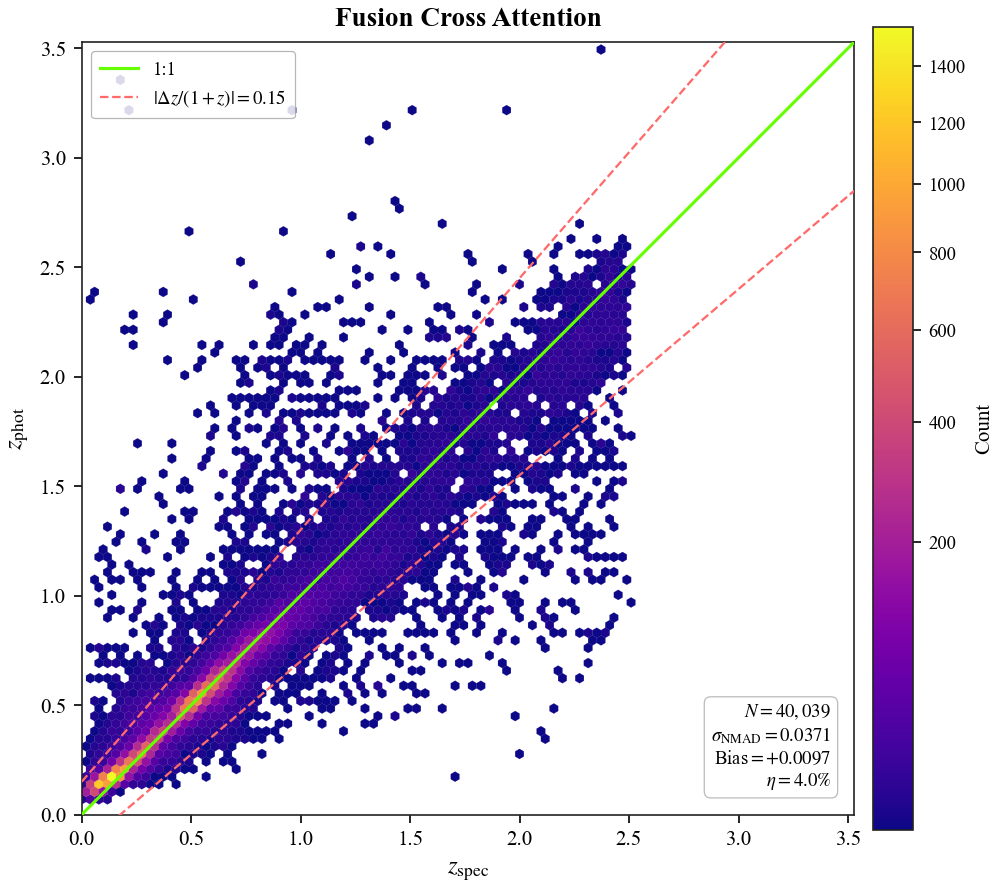

In [12]:
plot_pred_vs_true(
    y_true,
    y_pred,
    name="Fusion Cross Attention",
    save_path=os.path.join(BASE_REPORTS, "FusionCrossAttn_scatter.png"),
)

Binned performance saved → /Users/arpinejanunts/Desktop/Capstone/reports/FusionCrossAttn_binned.png


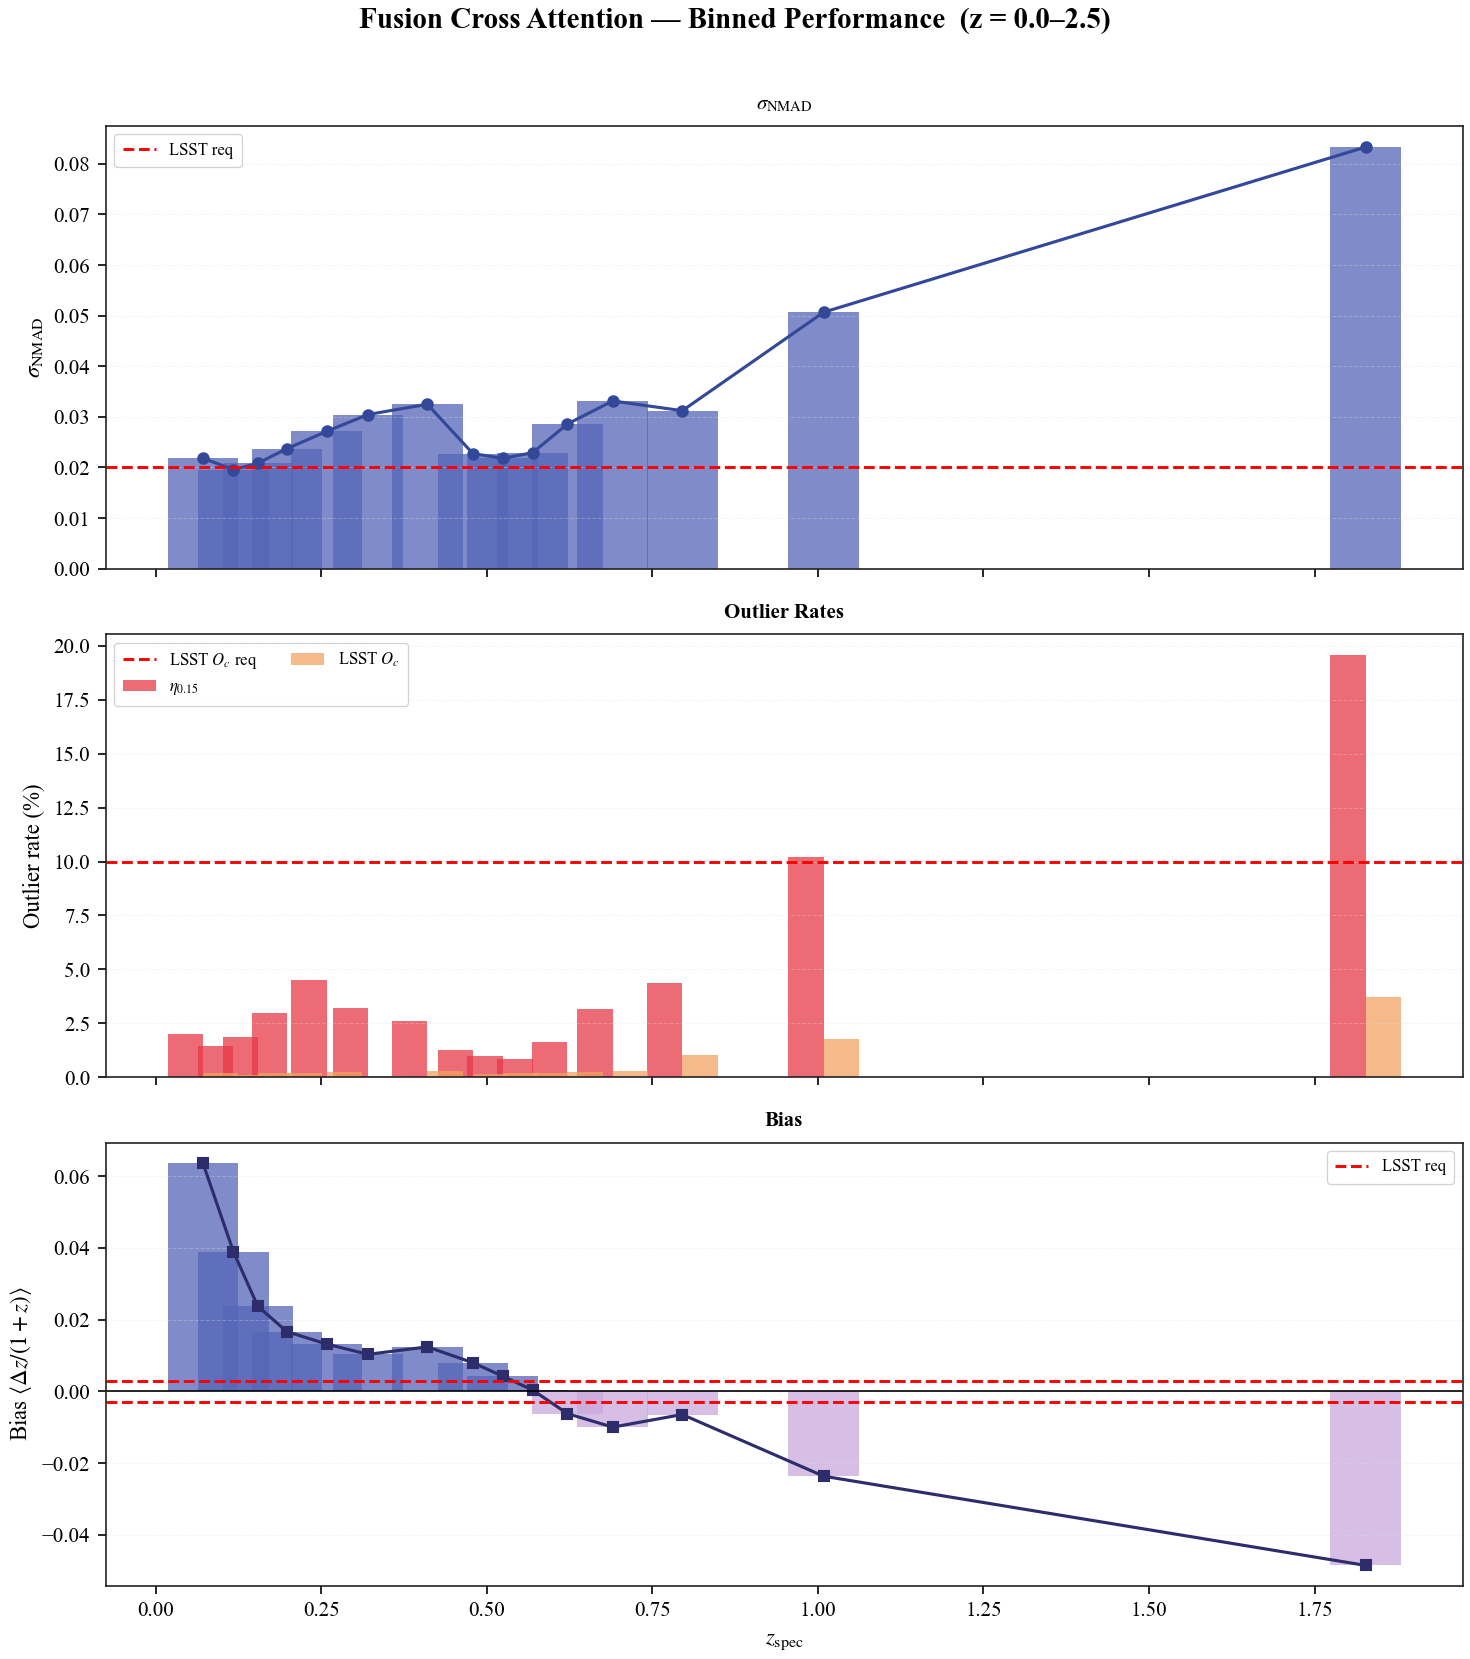

In [13]:
plot_binned_performance(
    y_true,
    y_pred,
    name="Fusion Cross Attention",
    n_bins=15,
    z_range=(0.0, 2.5),
    save_path=os.path.join(BASE_REPORTS, "FusionCrossAttn_binned.png"),
)

Figure saved → /Users/arpinejanunts/Desktop/Capstone/reports/FusionCrossAttn_full_eval.png


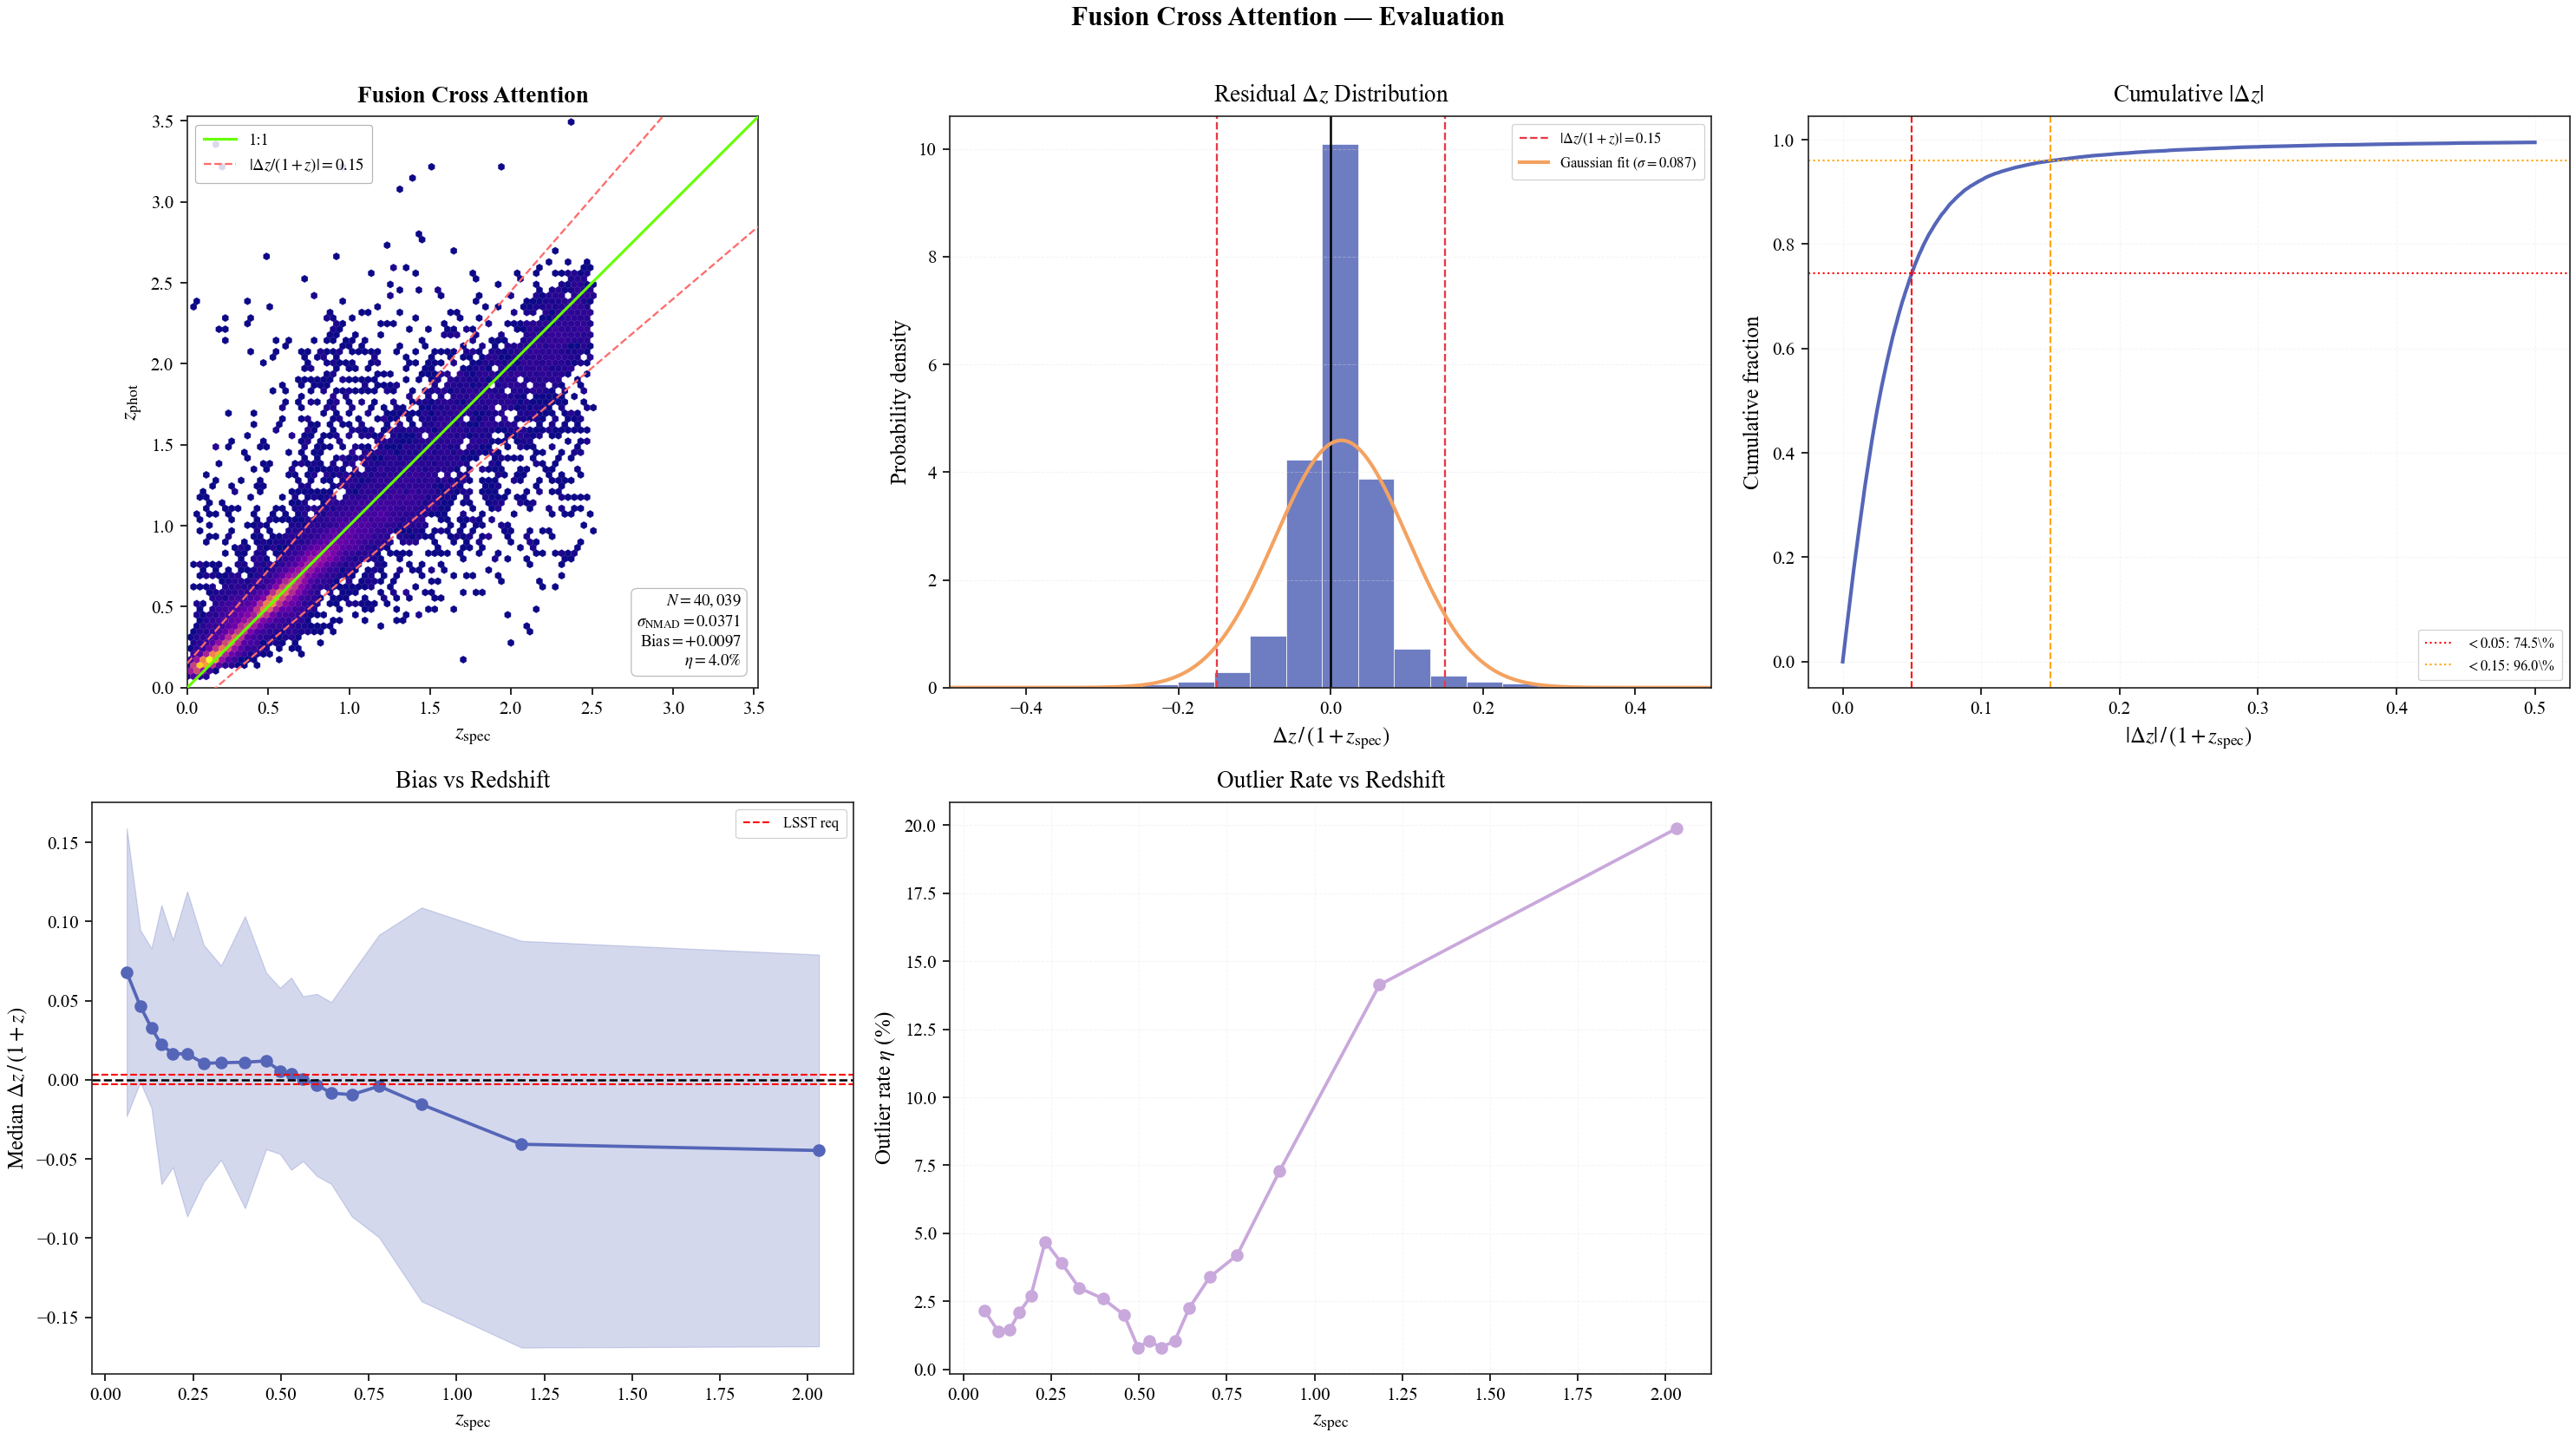

In [14]:
full_evaluation(
    name="Fusion Cross Attention",
    y_true=y_true,
    y_pred=y_pred,
    save_path=os.path.join(BASE_REPORTS, "FusionCrossAttn_full_eval.png"),
)